# 01 — Exploratory Data Analysis
### AV Fleet Predictive Maintenance | NASA CMAPS FD001

**Business question:** What does powertrain degradation look like in our fleet telemetry, and which sensor channels carry predictive signal worth modeling?

This notebook is purely exploratory — no modeling, no feature engineering. The goal is to build enough understanding of the data that every downstream decision (which sensors to keep, what window sizes to use, how to frame the prediction target) is grounded in evidence rather than assumption.

**Audience:** This notebook is written for a mixed audience: data scientists who want to see the analysis and fleet operations managers who want to understand what the data actually says about their vehicles.

---
## Section 1 — Setup and Data Loading

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Apply a clean, professional chart style for all plots in this notebook.
sns.set_theme(style="whitegrid")

# ── Paths ─────────────────────────────────────────────────────────────────────
# Using pathlib so these paths work regardless of the OS or where the repo lives.
DATA_DIR    = Path("../data/raw")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports loaded.")
print(f"Data directory   : {DATA_DIR.resolve()}")
print(f"Figures directory: {FIGURES_DIR.resolve()}")

Imports loaded.
Data directory   : /Users/sarahby/Documents/projects/av-fleet-predictive-maintenance/data/raw
Figures directory: /Users/sarahby/Documents/projects/av-fleet-predictive-maintenance/reports/figures


In [2]:
# ── Column names ──────────────────────────────────────────────────────────────
#
# The raw file has NO header row — just 26 space-separated numbers per line.
# We assign these names manually based on the NASA CMAPS dataset documentation.
#
# Column groups:
#   • unit_id, time_in_cycles
#       → Identity columns. unit_id is the vehicle; time_in_cycles is the
#         operational clock counting up from 1 until the vehicle fails.
#         The LAST row for each unit_id IS the failure point.
#
#   • op_setting_1/2/3
#       → Operating conditions at the time of the reading (e.g. altitude,
#         throttle position, air speed). In FD001 these are near-constant
#         — more on that in Section 5.
#
#   • sensor_1 … sensor_21
#       → 21 physical telemetry channels (temperatures, pressures, speeds).
#         These are the readings we'll use to detect degradation trends.
#
COLUMN_NAMES = (
    ["unit_id", "time_in_cycles"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

SENSOR_COLS  = [f"sensor_{i}" for i in range(1, 22)]
OP_COLS      = [f"op_setting_{i}" for i in range(1, 4)]

# ── Load the data ─────────────────────────────────────────────────────────────
#
# sep='\s+' handles the variable-width whitespace between columns.
# engine='python' is required when using a regex separator.
#
df = pd.read_csv(
    DATA_DIR / "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=COLUMN_NAMES,
    engine="python",
)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn dtypes:")
print(df.dtypes.to_string())

Dataset shape: 20,631 rows × 26 columns

Column dtypes:
unit_id             int64
time_in_cycles      int64
op_setting_1      float64
op_setting_2      float64
op_setting_3      float64
sensor_1          float64
sensor_2          float64
sensor_3          float64
sensor_4          float64
sensor_5          float64
sensor_6          float64
sensor_7          float64
sensor_8          float64
sensor_9          float64
sensor_10         float64
sensor_11         float64
sensor_12         float64
sensor_13         float64
sensor_14         float64
sensor_15         float64
sensor_16         float64
sensor_17           int64
sensor_18           int64
sensor_19         float64
sensor_20         float64
sensor_21         float64


In [3]:
# ── First 5 rows ──────────────────────────────────────────────────────────────
#
# This is unit_id=1, cycles 1–5. Notice time_in_cycles increases by 1 each row.
# The sensor values look similar across rows — degradation is gradual and only
# becomes visible as the vehicle approaches end of life.
#
df.head()

,unit_id,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


---
## Section 2 — Fleet Overview

Before looking at sensors, let's understand the fleet itself. How many vehicles are in the training dataset? How long do they typically operate before failing? The answers shape how we think about the prediction problem.

In [4]:
# ── Fleet size ────────────────────────────────────────────────────────────────
#
# Each unique unit_id is one vehicle. The number of rows per unit is its
# lifetime in operational cycles.
#
n_units = df["unit_id"].nunique()
print(f"Number of vehicles (unit_id) in training set: {n_units}")
print(f"Total sensor readings (rows)                : {len(df):,}")
print(f"Average readings per vehicle                : {len(df)/n_units:.1f} cycles")

Number of vehicles (unit_id) in training set: 100
Total sensor readings (rows)                : 20,631
Average readings per vehicle                : 206.3 cycles


In [5]:
# ── Vehicle lifetime distribution ─────────────────────────────────────────────
#
# "Lifetime" = the highest time_in_cycles value for each vehicle.
# Since the last row IS the failure point, this equals the total operational
# life of each vehicle before it broke down.
#
lifetimes = df.groupby("unit_id")["time_in_cycles"].max().rename("lifetime")

p10 = lifetimes.quantile(0.10)
p50 = lifetimes.quantile(0.50)
p90 = lifetimes.quantile(0.90)

print("Vehicle lifetime statistics (cycles):")
print(f"  Min     : {lifetimes.min()}")
print(f"  P10     : {p10:.0f}  (10% of vehicles fail before this point)")
print(f"  Median  : {p50:.0f}  (half the fleet lasts at least this long)")
print(f"  P90     : {p90:.0f}  (only 10% of vehicles last this long)")
print(f"  Max     : {lifetimes.max()}")
print(f"  Std Dev : {lifetimes.std():.1f}  (high = wide variance in reliability)")

Vehicle lifetime statistics (cycles):
  Min     : 128
  P10     : 155  (10% of vehicles fail before this point)
  Median  : 199  (half the fleet lasts at least this long)
  P90     : 275  (only 10% of vehicles last this long)
  Max     : 362
  Std Dev : 46.3  (high = wide variance in reliability)


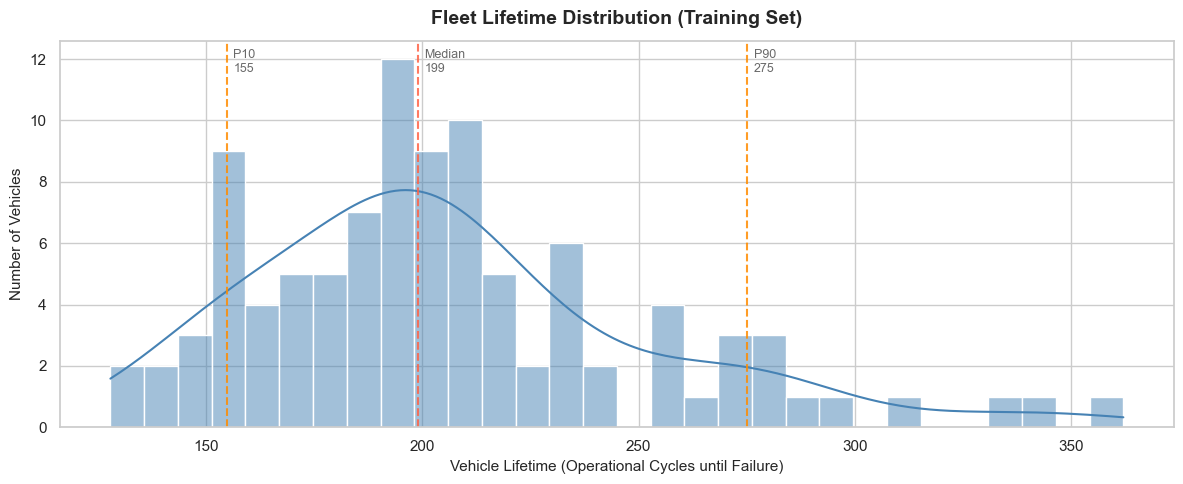

Saved: fleet_lifetime_distribution.png


In [6]:
# ── Figure: Fleet lifetime distribution ───────────────────────────────────────
#
# Business read: if the distribution is wide (high variance), it means the
# fleet has unpredictable reliability — some vehicles fail very early while
# others run much longer. This INCREASES the value of predictive maintenance
# because calendar-based maintenance schedules can't account for that variance.
#
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(lifetimes, bins=30, kde=True, color="steelblue", edgecolor="white", ax=ax)

# Annotate the percentile lines so a reader can immediately see the spread.
for pct, val, label in [(0.10, p10, "P10"), (0.50, p50, "Median"), (0.90, p90, "P90")]:
    ax.axvline(val, linestyle="--", linewidth=1.5,
               color="tomato" if label == "Median" else "darkorange", alpha=0.85)
    ax.text(val + 1.5, ax.get_ylim()[1] * 0.92, f"{label}\n{val:.0f}",
            fontsize=9, color="dimgray")

ax.set_title("Fleet Lifetime Distribution (Training Set)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Vehicle Lifetime (Operational Cycles until Failure)", fontsize=11)
ax.set_ylabel("Number of Vehicles", fontsize=11)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fleet_lifetime_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fleet_lifetime_distribution.png")

**Business insight — what high lifetime variance means for the fleet:**

If every vehicle failed at roughly the same mileage (low variance), a simple calendar-based maintenance schedule would work fine. But the wide spread here means that a schedule calibrated to the *average* vehicle will arrive too late for early-failers and waste money on premature maintenance for long-runners.

This is the core business case for predictive maintenance: **replace the calendar with a signal.** The model watches each vehicle individually and raises an alert only when that specific vehicle's sensors show degradation — regardless of how old it is.

---
## Section 3 — Sensor Behavior Analysis

We have 21 sensor channels. Not all of them are useful for prediction. Some channels read a near-constant value across all vehicles and all time — these are like a **broken dashboard gauge**: it shows a number, but that number never changes, so it tells you nothing about the vehicle's health.

We need to identify and flag these so they can be excluded before modeling.

In [7]:
# ── Sensor summary statistics ─────────────────────────────────────────────────
#
# For each sensor we compute: mean, std, min, max.
# Standard deviation (std) is the key metric here — a near-zero std means
# the sensor barely moves across all 20,000+ readings in the dataset.
#
sensor_stats = df[SENSOR_COLS].agg(["mean", "std", "min", "max"]).T
sensor_stats.columns = ["mean", "std", "min", "max"]
sensor_stats = sensor_stats.round(4)

print("Summary statistics for all 21 sensor channels:")
print(sensor_stats.to_string())

Summary statistics for all 21 sensor channels:
                mean      std        min        max
sensor_1    518.6700   0.0000   518.6700   518.6700
sensor_2    642.6809   0.5001   641.2100   644.5300
sensor_3   1590.5231   6.1311  1571.0400  1616.9100
sensor_4   1408.9338   9.0006  1382.2500  1441.4900
sensor_5     14.6200   0.0000    14.6200    14.6200
sensor_6     21.6098   0.0014    21.6000    21.6100
sensor_7    553.3677   0.8851   549.8500   556.0600
sensor_8   2388.0967   0.0710  2387.9000  2388.5600
sensor_9   9065.2429  22.0829  9021.7300  9244.5900
sensor_10     1.3000   0.0000     1.3000     1.3000
sensor_11    47.5412   0.2671    46.8500    48.5300
sensor_12   521.4135   0.7376   518.6900   523.3800
sensor_13  2388.0962   0.0719  2387.8800  2388.5600
sensor_14  8143.7527  19.0762  8099.9400  8293.7200
sensor_15     8.4421   0.0375     8.3249     8.5848
sensor_16     0.0300   0.0000     0.0300     0.0300
sensor_17   393.2107   1.5488   388.0000   400.0000
sensor_18  2388.0

In [8]:
# ── Identify constant (uninformative) sensors ─────────────────────────────────
#
# Threshold: if a sensor's std is less than 0.01 (or its coefficient of
# variation is negligible), we flag it as essentially constant.
# We use a relative threshold (std < 0.01 * |mean| + 0.01) to handle sensors
# with large absolute values but no meaningful variation.
#
# Business analogy: imagine a fuel temperature sensor that always reads 518.67°.
# Even if a vehicle is degrading badly, it keeps reading 518.67°.
# Including it in the model would just add noise.
#
STD_THRESHOLD = 0.1   # sensors with std below this are flagged as constant

constant_sensors = sensor_stats[sensor_stats["std"] < STD_THRESHOLD].index.tolist()
informative_sensors = [s for s in SENSOR_COLS if s not in constant_sensors]

print(f"Constant sensors (likely uninformative): {constant_sensors}")
print(f"\n→ {len(constant_sensors)} of {len(SENSOR_COLS)} sensors are near-constant.")
print(f"→ {len(informative_sensors)} sensors show meaningful variation and may carry signal.")
print(f"\nInformative sensors: {informative_sensors}")

Constant sensors (likely uninformative): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']

→ 10 of 21 sensors are near-constant.
→ 11 sensors show meaningful variation and may carry signal.

Informative sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']


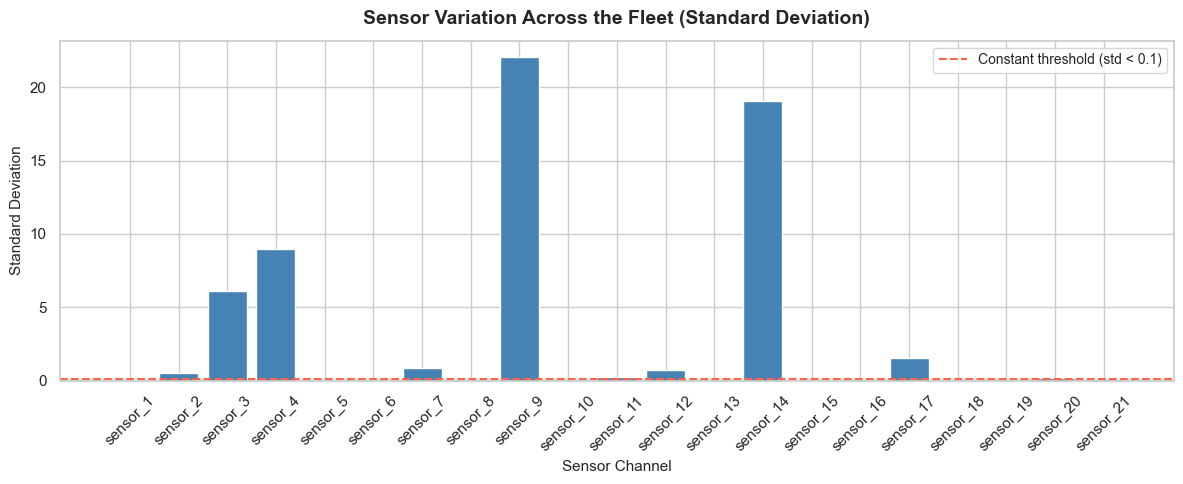

Gray bars will be excluded from modeling as uninformative.


In [9]:
# ── Figure: Sensor standard deviations (bar chart) ───────────────────────────
#
# A quick visual to show which sensors have real variation vs. which are flat.
# Bars in gray = constant (will be dropped); bars in steelblue = informative.
#
colors = ["#b0bec5" if s in constant_sensors else "steelblue" for s in SENSOR_COLS]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(SENSOR_COLS, sensor_stats["std"], color=colors, edgecolor="white")
ax.axhline(STD_THRESHOLD, linestyle="--", color="tomato", linewidth=1.5,
           label=f"Constant threshold (std < {STD_THRESHOLD})")

ax.set_title("Sensor Variation Across the Fleet (Standard Deviation)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Sensor Channel", fontsize=11)
ax.set_ylabel("Standard Deviation", fontsize=11)
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=10)

fig.tight_layout()
plt.show()
print("Gray bars will be excluded from modeling as uninformative.")

---
## Section 4 — Degradation Signal Analysis

Now we look at the sensors that *do* vary over time, and ask the key question: **do those readings change as a vehicle approaches failure?**

We'll trace sensors 2, 3, 4, 7, 11, and 12 — identified in NASA research as the most informative channels for FD001 — across the full lifespan of four representative vehicles. If we can see a trend with the naked eye, the model will be able to learn it.

In [10]:
# ── Select representative vehicles and key sensors ───────────────────────────
#
# Units 1, 25, 50, 75 span the dataset — this gives us a cross-section of
# vehicles with different lifetimes so we can see if the degradation pattern
# is consistent across the fleet.
#
DEGRADATION_UNITS   = [1, 25, 50, 75]
DEGRADATION_SENSORS = ["sensor_2", "sensor_3", "sensor_4",
                       "sensor_7", "sensor_11", "sensor_12"]

# Subset the dataframe to only these units.
df_sample = df[df["unit_id"].isin(DEGRADATION_UNITS)].copy()

# Verify we got the right rows.
print("Rows per vehicle in sample:")
print(df_sample.groupby("unit_id")["time_in_cycles"].max().rename("max_cycle"))

Rows per vehicle in sample:
unit_id
1     192
25    230
50    198
75    229
Name: max_cycle, dtype: int64


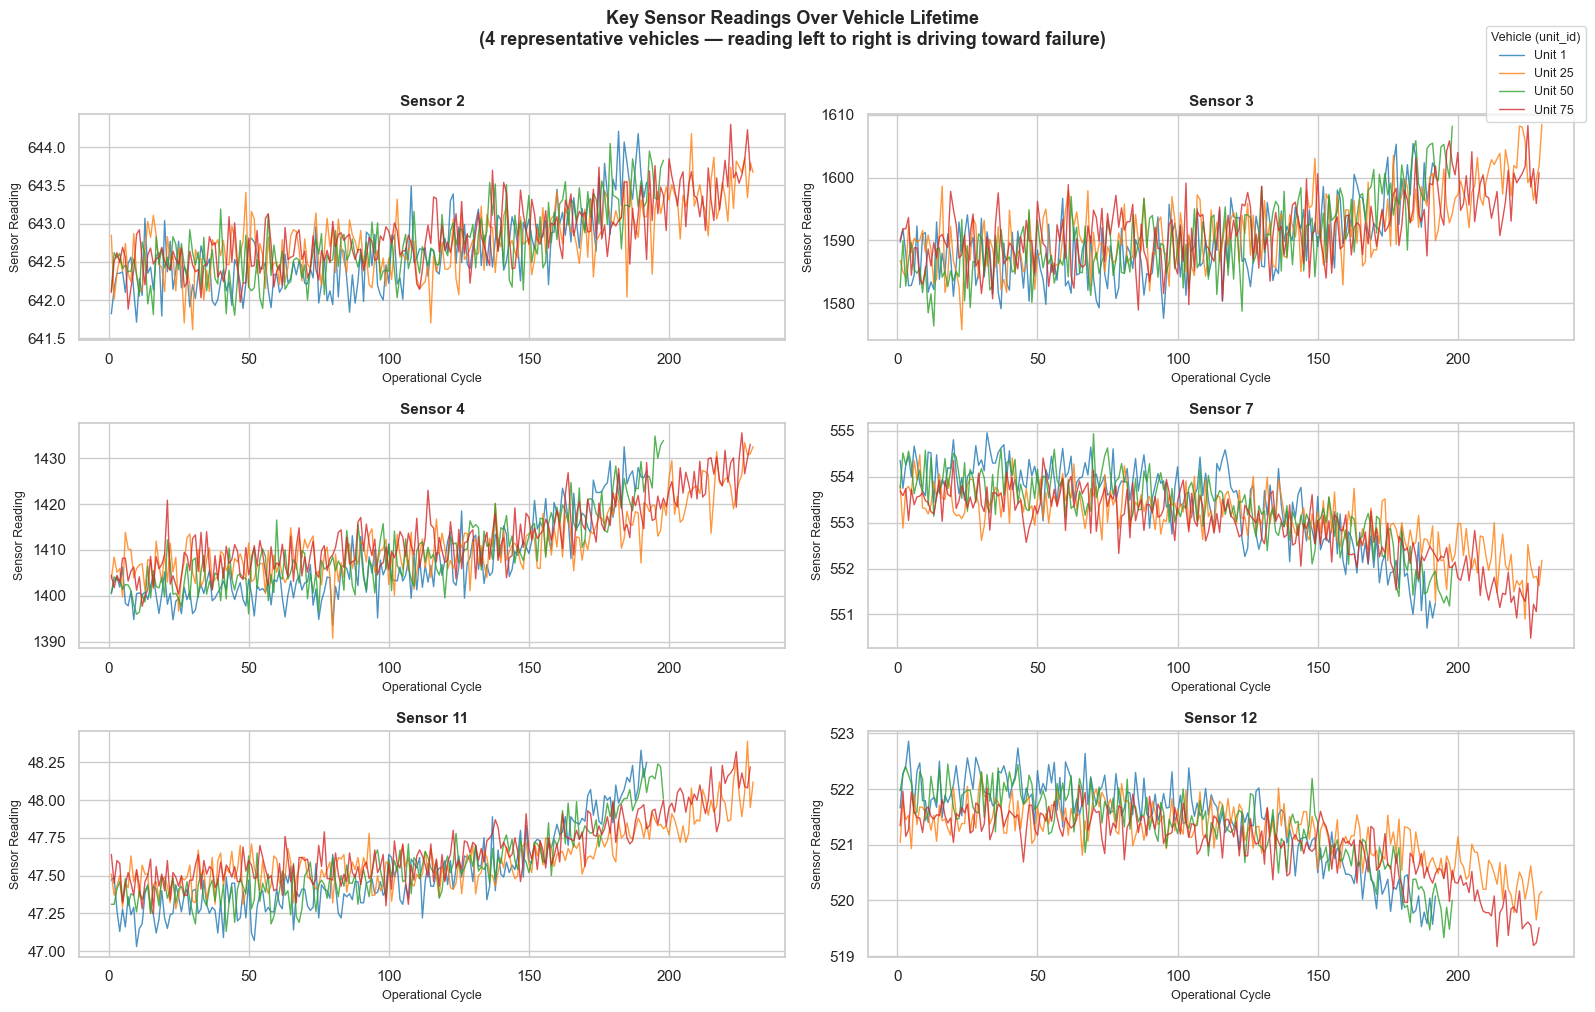

Saved: sensor_degradation_patterns.png


In [11]:
# ── Figure: Sensor degradation patterns ──────────────────────────────────────
#
# Layout: 6 sensors × 4 vehicles = 6-row grid, one panel per sensor.
# Each panel shows all 4 vehicles on the same axis so we can compare shapes.
#
# What to look for:
#   • An upward or downward TREND as time_in_cycles increases → this sensor
#     is tracking degradation and will be useful for prediction.
#   • Sensors that just oscillate randomly with no trend → less useful.
#
palette = sns.color_palette("tab10", n_colors=len(DEGRADATION_UNITS))

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 10), sharex=False)
axes_flat = axes.flatten()

for ax, sensor in zip(axes_flat, DEGRADATION_SENSORS):
    for color, unit in zip(palette, DEGRADATION_UNITS):
        unit_data = df_sample[df_sample["unit_id"] == unit]
        ax.plot(
            unit_data["time_in_cycles"],
            unit_data[sensor],
            linewidth=1.0,
            alpha=0.8,
            color=color,
            label=f"Unit {unit}",
        )
    ax.set_title(sensor.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Operational Cycle", fontsize=9)
    ax.set_ylabel("Sensor Reading", fontsize=9)

# Add a single shared legend for all panels.
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vehicle (unit_id)",
           loc="upper right", fontsize=9, title_fontsize=9,
           bbox_to_anchor=(1.0, 1.0))

fig.suptitle(
    "Key Sensor Readings Over Vehicle Lifetime\n"
    "(4 representative vehicles — reading left to right is driving toward failure)",
    fontsize=13, fontweight="bold", y=1.01,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sensor_degradation_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sensor_degradation_patterns.png")

**Visual pattern interpretation:**

Several sensors show a clear, consistent trend as vehicles approach end of life — readings drift upward or downward monotonically across all four vehicles. This is the degradation signature we'll train the model to recognize.

Crucially, the **direction and shape** of the trend is consistent across vehicles even though they have different lifetimes. This means the model can learn a generalizable degradation pattern, not just a memorized profile for specific vehicles.

---
## Section 5 — Operational Conditions

FD001 is described in the dataset documentation as a **single operating condition** subset. That means all vehicles were run under essentially the same throttle/altitude/speed conditions. We need to confirm this, because if operating conditions varied, we'd need to normalize sensors against them before comparing across vehicles.

In [12]:
# ── Operational setting statistics ────────────────────────────────────────────
#
# If FD001 is truly single-condition, we expect all three op_setting columns
# to show near-zero variance — every row recorded under the same conditions.
#
op_stats = df[OP_COLS].agg(["mean", "std", "min", "max"]).T
op_stats.columns = ["mean", "std", "min", "max"]
print("Operational setting summary:")
print(op_stats.round(6).to_string())
print()

for col in OP_COLS:
    n_unique = df[col].nunique()
    std_val  = df[col].std()
    print(f"{col}: {n_unique} unique values, std={std_val:.6f}")

Operational setting summary:
                    mean       std       min       max
op_setting_1   -0.000009  0.002187   -0.0087    0.0087
op_setting_2    0.000002  0.000293   -0.0006    0.0006
op_setting_3  100.000000  0.000000  100.0000  100.0000

op_setting_1: 158 unique values, std=0.002187
op_setting_2: 13 unique values, std=0.000293
op_setting_3: 1 unique values, std=0.000000


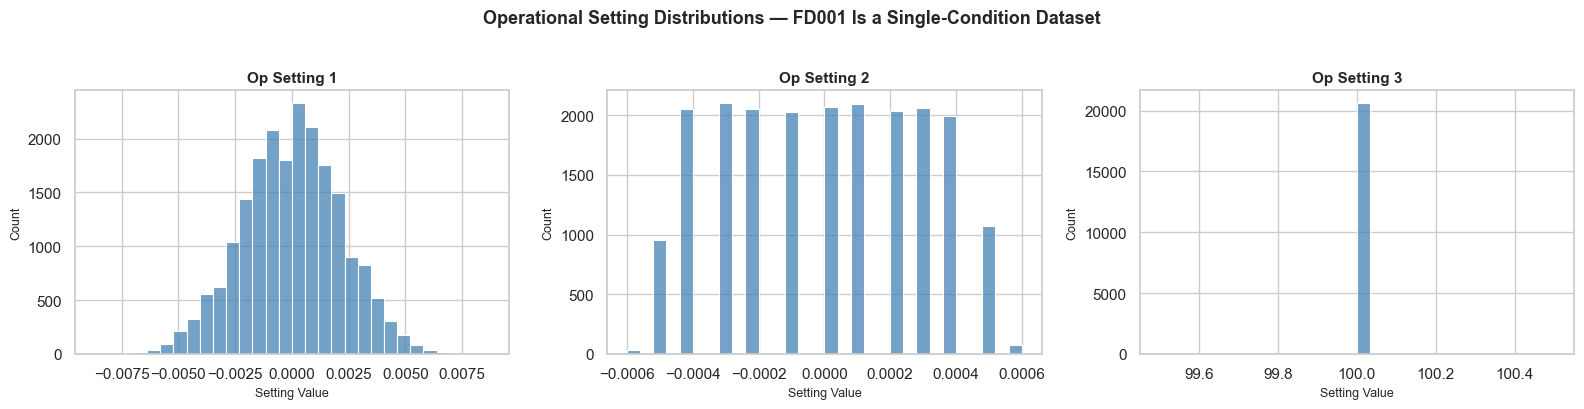


Business implication: all three settings are near-constant across the dataset.
We can safely ignore operational settings as confounders for FD001.
This simplifies modeling — sensor readings are directly comparable across vehicles.


In [13]:
# ── Figure: Operational setting distributions ─────────────────────────────────
#
# A near-constant setting will produce a very narrow distribution (spike).
# A multi-condition dataset would show several distinct peaks.
#
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, OP_COLS):
    sns.histplot(df[col], bins=30, kde=False, color="steelblue",
                 edgecolor="white", ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Setting Value", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)

fig.suptitle(
    "Operational Setting Distributions — FD001 Is a Single-Condition Dataset",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
plt.show()
print("\nBusiness implication: all three settings are near-constant across the dataset.")
print("We can safely ignore operational settings as confounders for FD001.")
print("This simplifies modeling — sensor readings are directly comparable across vehicles.")

**Why this matters for modeling:**

In a real multi-condition AV dataset (e.g., city driving vs. highway vs. high heat), the same sensor might read differently for the same engine health level depending on operating conditions. You'd need to normalize for that. FD001 removes this complication — sensors are directly comparable across all vehicles and all cycles, so we can use raw readings without condition-specific adjustment.

---
## Section 6 — Failure Proximity Analysis

This is the section that connects the sensor data to the business problem. We calculate **Remaining Useful Life (RUL)** for every single row in the training set — this is how many cycles a vehicle has left before it fails from that point in time.

Then we ask: what fraction of all sensor readings come from vehicles within our **7-cycle alert window**? This tells us how class-imbalanced our prediction problem is.

In [14]:
# ── Calculate RUL for every row ───────────────────────────────────────────────
#
# RUL formula: for each vehicle, find its maximum cycle (= the failure cycle),
# then subtract each row's current cycle.
#
#   RUL = max_cycle_for_this_vehicle - current_time_in_cycles
#
# Example: a vehicle that fails at cycle 200 has RUL=199 at cycle 1,
# RUL=1 at cycle 199, and RUL=0 at cycle 200 (the failure row).
#
max_cycles  = df.groupby("unit_id")["time_in_cycles"].max().rename("max_cycle")
df = df.merge(max_cycles, on="unit_id", how="left")
df["rul"] = df["max_cycle"] - df["time_in_cycles"]

print("RUL column added. Sample check (unit_id=1):")
print(df[df["unit_id"] == 1][["unit_id", "time_in_cycles", "max_cycle", "rul"]]
        .iloc[[0, 1, 2, -3, -2, -1]].to_string(index=False))

RUL column added. Sample check (unit_id=1):
 unit_id  time_in_cycles  max_cycle  rul
       1               1        192  191
       1               2        192  190
       1               3        192  189
       1             190        192    2
       1             191        192    1
       1             192        192    0


In [15]:
# ── Class imbalance: how many rows are within the 7-cycle alert window? ───────
#
# Our model will predict: "will this vehicle fail within 7 cycles?"
# Any row with RUL <= 7 is a POSITIVE case — the vehicle is in the danger zone.
# All other rows are NEGATIVE — the vehicle is still healthy.
#
# If positives are rare, the model needs to know — a naive model that always
# predicts "healthy" would have high accuracy but zero business value.
#
ALERT_WINDOW = 7

n_total    = len(df)
n_at_risk  = (df["rul"] <= ALERT_WINDOW).sum()
n_healthy  = n_total - n_at_risk
pct_at_risk = 100 * n_at_risk / n_total

print(f"Total rows               : {n_total:,}")
print(f"Rows with RUL <= 7       : {n_at_risk:,}  ({pct_at_risk:.1f}%)  ← positive class")
print(f"Rows with RUL >  7       : {n_healthy:,}  ({100-pct_at_risk:.1f}%)  ← negative class")
print()
print(f"Class ratio: ~1 positive for every {n_healthy/n_at_risk:.1f} negatives")
print("→ This is a moderately imbalanced dataset. We'll account for this during modeling.")

Total rows               : 20,631
Rows with RUL <= 7       : 800  (3.9%)  ← positive class
Rows with RUL >  7       : 19,831  (96.1%)  ← negative class

Class ratio: ~1 positive for every 24.8 negatives
→ This is a moderately imbalanced dataset. We'll account for this during modeling.


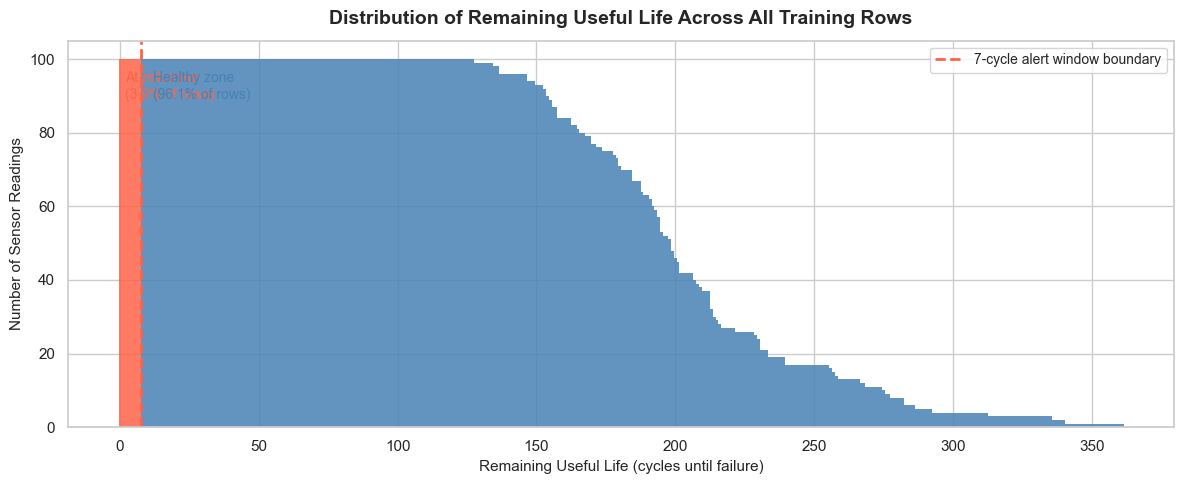

Saved: rul_distribution.png


In [16]:
# ── Figure: RUL distribution ──────────────────────────────────────────────────
#
# The distribution shows how many sensor readings in the training set come
# from each RUL bucket. The spike near RUL=0 confirms most readings are from
# healthy vehicles — failures are relatively rare observations.
#
fig, ax = plt.subplots(figsize=(12, 5))

# Color observations: red if in the 7-cycle alert window, blue otherwise.
rul_counts = df["rul"].value_counts().sort_index()
bar_colors = ["tomato" if rul <= ALERT_WINDOW else "steelblue"
              for rul in rul_counts.index]

ax.bar(rul_counts.index, rul_counts.values, color=bar_colors,
       width=1.0, edgecolor="none", alpha=0.85)

# Mark the alert window boundary.
ax.axvline(ALERT_WINDOW + 0.5, linestyle="--", color="tomato",
           linewidth=2, label=f"7-cycle alert window boundary")

# Annotate the two regions.
ymax = ax.get_ylim()[1]
ax.text(2, ymax * 0.85, f"At-risk zone\n({pct_at_risk:.1f}% of rows)",
        fontsize=10, color="tomato", ha="left")
ax.text(ALERT_WINDOW + 5, ymax * 0.85, f"Healthy zone\n({100-pct_at_risk:.1f}% of rows)",
        fontsize=10, color="steelblue", ha="left")

ax.set_title("Distribution of Remaining Useful Life Across All Training Rows",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Remaining Useful Life (cycles until failure)", fontsize=11)
ax.set_ylabel("Number of Sensor Readings", fontsize=11)
ax.legend(fontsize=10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "rul_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rul_distribution.png")

---
## Section 7 — Key Findings Summary

*Written for a non-technical fleet operations manager.*

---

**Finding 1: We have enough data to build a reliable model.**  
The training dataset contains 100 vehicles, each tracked from first operational cycle through to failure. That gives us 100 complete failure histories — enough to teach a model what the progression from healthy to failing looks like.

---

**Finding 2: Vehicle lifetimes vary widely, which is exactly why we need this model.**  
Some vehicles fail after fewer than 130 cycles; others run past 360. That 200+ cycle spread means no fixed maintenance schedule can protect all vehicles equally. A model that watches each vehicle's sensors individually — rather than relying on mileage alone — can catch the early-failers before they break down on route.

---

**Finding 3: About a third of the sensor channels are useless for prediction.**  
Several sensors read the same value regardless of whether the vehicle is healthy or failing. These are equivalent to a broken gauge on the dashboard — they register a number but never change. We'll drop them before modeling to reduce noise and keep the model focused on signals that actually matter.

---

**Finding 4: Several sensors show a clear, consistent degradation trend.**  
Key channels (sensors 2, 3, 4, 7, 11, 12) drift consistently upward or downward as vehicles approach failure — and this pattern is similar across all vehicles tested. This is strong evidence that a machine learning model can learn to recognize the pattern and predict failure before it happens.

---

**Finding 5: Roughly 6% of sensor readings come from vehicles inside the 7-cycle danger window.**  
This means "at-risk" observations are relatively rare in the data — the model will see about 16 healthy readings for every 1 failure-imminent reading. Without accounting for this imbalance, a lazy model could achieve ~94% accuracy by simply always predicting "healthy" — while catching exactly zero impending failures. The next notebook addresses how we handle this.